## Imports

In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc
from adam_core.time import Timestamp
from astropy.time import Time
import matplotlib.pyplot as plt
import quivr as qv
import numpy as np
import pickle
import requests
import scipy
import scipy.stats
import scipy.optimize
from typing import Dict, Tuple, Optional
from adam_core.constants import DE44X_CONSTANTS

## Type Definitions

In [2]:
class RotationalPeriodInput(qv.Table):
    """Per-observation inputs for rotational period analysis:
    heliocentric and topocentric distances and phase angle from Horizons."""
    object_id = qv.LargeStringColumn()
    obs_time = Timestamp.as_column()
    sun_range = qv.Float64Column()   # heliocentric distance r [AU]
    obs_range = qv.Float64Column()   # topocentric distance Δ [AU]
    angle = qv.Float64Column()       # Sun-Target-Observer phase angle α [deg]

In [3]:
class FourierFitResult(qv.Table):
    """One row per Fourier order k (2–6) tried by run_fourier.
    Stores the best-fit frequency and residual found for that k."""
    k = qv.Int64Column(nullable=True)             # Fourier order
    sigma2 = qv.Float64Column(nullable=True)      # best weighted residual (minimized over freq grid)
    freq = qv.Float64Column(nullable=True)        # best frequency [cycles/day]; period_h = 24/freq
    n_included = qv.Int64Column(nullable=True)    # observations retained after outlier rejection
    # Fit coefficients [c1, c2, A1, B1, ..., Ak, Bk, H_g, H_i, H_r, H_u], length = 2+2k+4
    # In case G12* fit, c1=1e6, c2=G12*. In case known G1,G2, c1=index of G_VALUES and c2=1e6
    values = qv.LargeListColumn(pa.float64(), nullable=True)

In [4]:
class FourierFullResult(qv.Table):
    """Complete output of Fourier fit"""
    object_id = qv.LargeStringColumn()
    num_obs = qv.Int64Column(nullable=True) # Total number of observations available, with outliers
    arc_days = qv.Float64Column(nullable=True)
    intermediate_result = qv.BinaryColumn(nullable = True) # Multiple rows of FourierFitResult
    selected_k = qv.Int64Column(nullable=True)
    count_local_maxima = qv.Int64Column(nullable=True)
    period_h = qv.Float64Column(nullable=True)
    amplitude = qv.Float64Column(nullable=True)
    color_gr = qv.Float64Column(nullable=True)
    color_gi = qv.Float64Column(nullable=True)
    color_ri = qv.Float64Column(nullable=True)
    elongation = qv.Float64Column(nullable=True)

In [5]:
class PaperTable2(qv.Table):
    """Table 2 from Greenstreet et al. 2026 (ApJL 996 L33).
    Reference results for 78 near-Earth asteroids: periods, amplitudes, colors."""
    designation = qv.LargeStringColumn()
    h_mag = qv.Float64Column()
    mean_mag_r = qv.Float64Column()
    num_observations = qv.Int64Column()
    arc_days = qv.Int64Column()
    period_lsm = qv.Float64Column()      # [h]
    period_fourier = qv.Float64Column()  # [h]
    amplitude_lsm = qv.Float64Column()
    amplitude_fourier = qv.Float64Column()
    g_minus_r_lsm = qv.Float64Column()
    g_minus_r_fourier = qv.Float64Column()
    g_minus_i_lsm = qv.Float64Column()
    g_minus_i_fourier = qv.Float64Column()
    r_minus_i_lsm = qv.Float64Column()
    r_minus_i_fourier = qv.Float64Column()
    axial_elongation = qv.Float64Column()


_designation = [
    "2025 MA19", "2025 MA45", "2025 MA46", "2025 MC34", "2025 MD38",
    "2025 MD40", "2025 MD67", "2025 MD76", "2025 ME15", "2025 ME24",
    "2025 ME68", "2025 MF76", "2025 MG17", "2025 MG56", "2025 MH40",
    "2025 MH69", "2025 MH75", "2025 MH86", "2025 MJ13", "2025 MJ21",
    "2025 MJ23", "2025 MJ30", "2025 MJ71", "2025 MJ79", "2025 MK23",
    "2025 MK41", "2025 MK68", "2025 MK83", "2025 MK88",
    "2025 ML10", "2025 ML17", "2025 ML35", "2025 ML52", "2025 ML53",
    "2025 MM37", "2025 MM81", "2025 MM82", "2025 MN25", "2025 MN37",
    "2025 MN45", "2025 MN7",  "2025 MO35", "2025 MO39", "2025 MO47",
    "2025 MO79", "2025 MP21", "2025 MP47", "2025 MP61", "2025 MP67",
    "2025 MP71", "2025 MQ58", "2025 MR33", "2025 MS34", "2025 MS7",
    "2025 MT24", "2025 MU10", "2025 MU15", "2025 MU24",
    "2025 MU59", "2025 MU8",  "2025 MU9",  "2025 MV19", "2025 MV31",
    "2025 MV38", "2025 MV4",  "2025 MV46", "2025 MV71", "2025 MW70",
    "2025 MX34", "2025 MX44", "2025 MX50", "2025 MX63", "2025 MX69",
    "2025 MY23", "2025 MY77", "2025 MZ78",
]
_h_mag = [
    18.1, 19.5, 18.1, 18.5, 18.0, 19.0, 18.1, 18.3, 19.8, 18.4,
    21.2, 18.9, 17.1, 18.9, 19.1, 19.1, 19.0, 18.2, 20.9, 18.8,
    17.9, 18.0, 22.70, 20.0, 20.4, 19.3, 19.1, 20.1, 18.4,
    18.3, 18.5, 19.4, 18.8, 18.4, 19.6, 21.1, 19.0, 20.5, 17.8,
    18.7, 18.1, 18.4, 19.3, 18.5, 20.1, 17.9, 18.8, 18.4, 19.0,
    18.3, 18.4, 18.3, 18.3, 18.5, 17.8, 20.6, 21.6, 18.7,
    19.0, 19.0, 18.4, 18.0, 18.8, 17.9, 19.6, 17.8, 18.2, 18.5,
    19.4, 17.9, 19.8, 19.1, 19.2, 18.9, 18.1, 17.8,
]
_mean_mag_r = [
    22.66, 22.50, 23.13, 23.02, 22.80, 23.35, 22.36, 23.02, 22.95, 23.32,
    23.51, 21.82, 22.76, 22.86, 22.56, 23.12, 22.67, 23.00, 23.06, 22.22,
    22.69, 22.82, 23.44, 23.92, 22.58, 22.17, 22.16, 22.77, 23.19,
    23.20, 23.28, 23.10, 22.91, 22.83, 22.40, 22.90, 22.96, 22.95, 22.20,
    22.24, 23.00, 22.37, 22.84, 23.43, 23.27, 22.67, 22.73, 23.51, 22.75,
    22.23, 23.11, 22.40, 23.05, 23.04, 22.15, 22.32, 23.53, 22.79,
    22.00, 23.22, 22.72, 22.60, 22.98, 22.91, 23.36, 22.47, 22.74, 22.45,
    22.37, 23.21, 22.14, 23.22, 22.51, 22.10, 22.51, 23.21,
]
_num_observations = [
    447, 140, 291, 321, 458, 393, 232, 404, 329, 386,
    192, 244, 289, 213, 379, 314, 399, 456, 116, 262,
    121, 291, 272, 70, 112, 426, 147, 333, 234,
    294, 255, 411, 436, 121, 305, 390, 412, 318, 424,
    517, 347, 417, 141, 279, 122, 314, 398, 268, 194,
    359, 314, 490, 292, 114, 408, 450, 182, 475,
    503, 276, 324, 254, 277, 241, 350, 502, 334, 265,
    174, 488, 432, 327, 213, 199, 258, 167,
]
_arc_days = [
    9, 12, 12, 12, 12, 12, 2, 12, 12, 12,
    12, 6, 6, 12, 9, 12, 12, 12, 12, 4,
    2, 12, 6, 6, 12, 12, 2, 12, 12,
    6, 12, 12, 12, 12, 9, 9, 12, 12, 9,
    12, 12, 12, 2, 12, 9, 12, 12, 9, 4,
    12, 12, 12, 6, 2, 9, 6, 12, 6,
    12, 12, 6, 6, 6, 6, 12, 12, 12, 12,
    2, 12, 12, 9, 4, 12, 6, 4,
]
_period_lsm = [
    8.9, 1.6, 5.9, 8.4, 15.8, 4.4, 7.8, 11.0, 6.9, 2.9,
    0.9, 2.2, 4.3, 0.3, 8.0, 6.7, 4.2, 4.4, 3.4, 3.4,
    7.4, 5.6, 0.031, 1.0, 6.2, 0.063, 5.0, 6.1, 2.7,
    7.0, 6.7, 21.3, 11.5, 5.2, 3.7, 1.1, 5.0, 0.4, 4.8,
    0.031, 6.8, 6.3, 4.9, 9.1, 5.5, 6.2, 4.9, 3.0, 4.1,
    9.1, 2.9, 3.5, 2.3, 4.6, 8.9, 6.5, 0.4, 2.2,
    8.2, 0.8, 4.9, 7.4, 5.2, 6.0, 5.9, 3.4, 0.2, 3.9,
    5.8, 1.1, 1.9, 8.3, 9.1, 3.1, 7.6, 1.2,
]
_period_fourier = [
    8.9, 1.6, 5.9, 8.4, 9.5, 4.4, 3.3, 11.0, 8.1, 4.2,
    0.9, 2.0, 4.3, 0.3, 6.9, 7.8, 4.2, 4.4, 3.1, 3.9,
    5.2, 5.6, 0.031, 0.4, 10.6, 0.063, 5.0, 6.1, 2.5,
    7.0, 6.7, 21.3, 9.2, 7.0, 1.9, 1.1, 5.0, 0.4, 6.8,
    0.031, 10.6, 6.3, 6.2, 9.1, 2.7, 5.5, 2.2, 5.6, 6.2,
    9.1, 3.1, 3.5, 2.3, 4.6, 8.9, 6.5, 0.4, 2.2,
    8.2, 0.8, 3.5, 7.4, 5.8, 6.0, 5.3, 3.4, 0.2, 3.9,
    4.7, 1.2, 1.9, 8.3, 7.7, 3.1, 7.6, 1.2,
]
_amplitude_lsm = [
    0.7, 0.7, 0.6, 0.8, 1.1, 0.7, 1.2, 0.7, 0.9, 0.3,
    0.6, 0.2, 0.4, 0.5, 1.4, 0.7, 0.5, 0.5, 0.6, 0.3,
    0.8, 0.5, 0.4, 0.2, 0.9, 0.2, 0.7, 0.5, 0.4,
    1.0, 0.6, 0.8, 0.7, 0.7, 0.3, 1.0, 0.8, 0.4, 0.8,
    0.4, 0.7, 0.5, 0.9, 0.7, 0.6, 0.6, 0.4, 0.6, 0.7,
    0.4, 0.3, 0.3, 0.5, 0.8, 1.0, 0.5, 0.5, 0.3,
    0.6, 0.6, 0.6, 0.7, 0.7, 0.6, 0.8, 0.2, 0.4, 0.2,
    0.7, 0.2, 0.3, 0.7, 0.7, 0.2, 1.0, 0.5,
]
_amplitude_fourier = [
    1.0, 0.6, 0.6, 0.9, 1.1, 0.7, 0.5, 0.6, 0.9, 0.4,
    0.5, 0.1, 0.4, 0.8, 0.7, 0.7, 0.4, 0.5, 0.9, 0.3,
    0.9, 0.5, 0.4, 0.2, 1.7, 0.3, 0.6, 0.5, 0.4,
    1.1, 0.6, 1.0, 0.7, 0.8, 0.3, 1.2, 0.9, 0.4, 0.9,
    0.4, 0.7, 0.5, 1.0, 0.7, 0.6, 0.5, 0.3, 0.7, 0.7,
    0.4, 0.4, 0.2, 0.5, 0.7, 1.1, 0.5, 0.5, 0.2,
    0.6, 0.6, 0.7, 0.7, 0.6, 0.6, 0.6, 0.1, 0.6, 0.3,
    0.8, 0.3, 0.3, 0.5, 1.3, 0.2, 1.1, 0.5,
]
_g_minus_r_lsm = [
    0.44, 0.35, 0.53, 0.52, 0.46, 0.45, 0.50, 0.46, 0.61, 0.51,
    0.59, 0.56, 0.46, 0.47, 0.47, 0.63, 0.58, 0.44, 0.46, 0.43,
    0.64, 0.50, 0.58, 0.47, 0.65, 0.41, 0.50, 0.58, 0.60,
    0.50, 0.37, 0.54, 0.54, 0.38, 0.52, 0.55, 0.73, 0.42, 0.56,
    0.43, 0.47, 0.57, 0.46, 0.44, 0.57, 0.52, 0.43, 0.49, 0.63,
    0.57, 0.60, 0.68, 0.59, 0.49, 0.63, 0.52, 0.50, 0.66,
    0.54, 0.47, 0.48, 0.46, 0.43, 0.68, 0.47, 0.55, 0.44, 0.63,
    0.67, 0.41, 0.64, 0.60, 0.52, 0.57, 0.60, 0.46,
]
_g_minus_r_fourier = [
    0.46, 0.45, 0.53, 0.49, 0.46, 0.44, 0.51, 0.49, 0.63, 0.51,
    0.58, 0.58, 0.46, 0.48, 0.43, 0.63, 0.58, 0.44, 0.32, 0.40,
    0.56, 0.50, 0.58, 0.42, 0.56, 0.40, 0.63, 0.55, 0.62,
    0.54, 0.40, 0.58, 0.55, 0.42, 0.48, 0.53, 0.74, 0.41, 0.54,
    0.42, 0.47, 0.56, 0.37, 0.43, 0.62, 0.54, 0.47, 0.55, 0.62,
    0.57, 0.65, 0.66, 0.58, 0.47, 0.49, 0.52, 0.48, 0.64,
    0.58, 0.46, 0.47, 0.46, 0.54, 0.68, 0.48, 0.52, 0.43, 0.62,
    0.63, 0.42, 0.63, 0.59, 0.49, 0.58, 0.61, 0.46,
]
_g_minus_i_lsm = [
    0.49, 0.65, 0.71, 0.69, 0.54, 0.59, 0.72, 0.65, 0.78, 0.70,
    0.75, 0.75, 0.59, 0.59, 0.58, 0.81, 0.82, 0.54, 0.48, 0.49,
    0.71, 0.67, 0.78, 0.65, 0.63, 0.55, 0.58, 0.73, 0.80,
    0.57, 0.48, 0.78, 0.67, 0.63, 0.58, 0.67, 0.88, 0.51, 0.73,
    0.56, 0.62, 0.71, 0.47, 0.72, 0.69, 0.65, 0.48, 0.70, 0.79,
    0.83, 0.78, 0.83, 0.74, 0.58, 0.64, 0.67, 0.69, 0.80,
    0.79, 0.58, 0.61, 0.68, 0.71, 0.86, 0.58, 0.70, 0.57, 0.90,
    0.91, 0.56, 0.81, 0.80, 0.53, 0.72, 0.80, 0.58,
]
_g_minus_i_fourier = [
    0.55, 0.60, 0.68, 0.70, 0.59, 0.58, 0.59, 0.65, 0.79, 0.70,
    0.76, 0.75, 0.58, 0.59, 0.55, 0.93, 0.83, 0.53, 0.82, 0.50,
    0.767, 0.68, 0.76, 0.71, 0.77, 0.56, 0.81, 0.67, 0.84,
    0.64, 0.49, 0.82, 0.75, 0.64, 0.59, 0.66, 0.83, 0.54, 0.75,
    0.57, 0.59, 0.71, 0.44, 0.74, 0.71, 0.72, 0.62, 0.70, 0.83,
    0.78, 0.74, 0.87, 0.75, 0.56, 0.62, 0.66, 0.69, 0.80,
    0.77, 0.58, 0.57, 0.66, 0.67, 0.91, 0.64, 0.67, 0.57, 0.90,
    0.83, 0.54, 0.83, 0.79, 0.56, 0.72, 0.91, 0.60,
]
_r_minus_i_lsm = [
    0.05, 0.30, 0.18, 0.16, 0.08, 0.14, 0.21, 0.18, 0.17, 0.19,
    0.16, 0.19, 0.13, 0.12, 0.11, 0.18, 0.23, 0.10, 0.02, 0.06,
    0.06, 0.16, 0.20, 0.18, -0.02, 0.14, 0.08, 0.14, 0.20,
    0.07, 0.10, 0.24, 0.13, 0.25, 0.06, 0.12, 0.15, 0.08, 0.18,
    0.13, 0.15, 0.14, 0.01, 0.28, 0.12, 0.13, 0.04, 0.21, 0.16,
    0.25, 0.18, 0.15, 0.15, 0.09, 0.01, 0.15, 0.19, 0.13,
    0.25, 0.12, 0.13, 0.23, 0.27, 0.18, 0.11, 0.15, 0.13, 0.28,
    0.23, 0.16, 0.17, 0.20, 0.01, 0.15, 0.20, 0.12,
]
_r_minus_i_fourier = [
    0.08, 0.14, 0.15, 0.21, 0.13, 0.14, 0.07, 0.16, 0.16, 0.19,
    0.18, 0.17, 0.13, 0.11, 0.12, 0.30, 0.24, 0.09, 0.50, 0.10,
    0.21, 0.17, 0.18, 0.3, 0.2, 0.16, 0.18, 0.12, 0.22,
    0.10, 0.10, 0.24, 0.20, 0.21, 0.11, 0.12, 0.09, 0.13, 0.21,
    0.14, 0.12, 0.15, 0.07, 0.31, 0.09, 0.17, 0.15, 0.15, 0.21,
    0.20, 0.10, 0.21, 0.17, 0.08, 0.13, 0.14, 0.21, 0.16,
    0.20, 0.12, 0.10, 0.20, 0.13, 0.23, 0.16, 0.15, 0.13, 0.28,
    0.20, 0.12, 0.20, 0.20, 0.06, 0.14, 0.30, 0.14,
]
_axial_elongation = [
    2.1, 1.5, 1.6, 1.9, 2.2, 1.7, 1.4, 1.6, 1.9, 1.3,
    1.4, 1.1, 1.3, 1.7, 1.7, 1.7, 1.3, 1.5, 1.8, 1.2,
    2.0, 1.4, 1.3, 1.2, 3.1, 1.2, 1.5, 1.4, 1.4,
    2.2, 1.5, 2.0, 1.7, 1.8, 1.2, 2.1, 1.9, 1.3, 2.0,
    1.3, 1.7, 1.4, 1.9, 1.7, 1.6, 1.5, 1.2, 1.7, 1.6,
    1.4, 1.3, 1.2, 1.4, 1.7, 2.2, 1.3, 1.4, 1.2,
    1.5, 1.5, 1.7, 1.7, 1.6, 1.6, 1.5, 1.1, 1.6, 1.2,
    1.7, 1.3, 1.2, 1.4, 2.4, 1.1, 2.2, 1.5,
]

paper_table2 = PaperTable2.from_kwargs(
    designation=_designation,
    h_mag=_h_mag,
    mean_mag_r=_mean_mag_r,
    num_observations=_num_observations,
    arc_days=_arc_days,
    period_lsm=_period_lsm,
    period_fourier=_period_fourier,
    amplitude_lsm=_amplitude_lsm,
    amplitude_fourier=_amplitude_fourier,
    g_minus_r_lsm=_g_minus_r_lsm,
    g_minus_r_fourier=_g_minus_r_fourier,
    g_minus_i_lsm=_g_minus_i_lsm,
    g_minus_i_fourier=_g_minus_i_fourier,
    r_minus_i_lsm=_r_minus_i_lsm,
    r_minus_i_fourier=_r_minus_i_fourier,
    axial_elongation=_axial_elongation,
)

## Data pull from New Horizons

In [6]:
def _parse_rotational_period_input_response(object_id: str, text: str) -> RotationalPeriodInput:
    lines = text.splitlines()
    row = 0
    while row < len(lines) and not lines[row].startswith("$$SOE"):
        row += 1
    row += 1
    jd = []
    sun_range = []
    obs_range = []
    angle = []
    while row < len(lines) and not lines[row].startswith("$$EOE"):
        parts = lines[row].split(",")
        # text date, JD data, solar presence, lunar presence, sun range to target AU,
        # observer range to target AU, Sun-Target-Observer angle degrees, <-- extra comma
        assert len(parts) >= 7, f"Actual length {len(parts)}: {parts}"
        jd.append(float(parts[1]))
        sun_range.append(float(parts[4]))
        obs_range.append(float(parts[5]))
        angle.append(float(parts[6]))
        row += 1
    return RotationalPeriodInput.from_kwargs(
        object_id = [object_id] * len(jd),
        obs_time = Timestamp.from_jd(jd),
        sun_range = sun_range,
        obs_range = obs_range,
        angle = angle,
    )


def _query_rotational_period_inputs(object_id: str, stn: str, obs_times: pa.DoubleArray) -> RotationalPeriodInput:
    API_URL = "https://ssd.jpl.nasa.gov/api/horizons.api"
    chunk_size = 30 # 100 is too much
    start_chunk = 0
    sess = requests.Session() # TODO: parallel queries?
    # Selected: 
    # "19: heliocentric range and range rate"
    # "20: observer range and range rate"
    # "24: Sun-target-observer ~PHASE angle"
    # Suppress rates, only use ranges
    params = {
        "format": "text",
        "COMMAND": f"'DES={object_id};'",
        "OBJ_DATA": "NO", # default YES
        # "MAKE_EPHEM": "YES", # default
        #"EPHEM_TYPE": "OBSERVER", # default
        "CENTER": stn,
        "TIME_TYPE": "UT",
        "TLIST_TYPE": "MJD",
        "QUANTITIES": "'19,20,24'",
        "CAL_FORMAT": "BOTH", # CAL & JD
        "CSV_FORMAT": "YES",
        # "RANGE_UNITS": "AU", # default
        "SUPPRESS_RANGE_RATE": "YES", # default NO
    }
    collections = []
    while start_chunk < len(obs_times):
        tlist = [f"'{v}'" for v in obs_times[start_chunk:start_chunk+chunk_size]]
        start_chunk += chunk_size
        params["TLIST"] = " ".join(tlist)
        resp = sess.get(
            API_URL, params=params, timeout=10
        )
        resp.raise_for_status()
        collections.append(_parse_rotational_period_input_response(object_id, resp.text))
    return qv.concatenate(collections)

def cache_or_query_rotational_period_inputs(object_id: str,
                                            stn: str,
                                            obs_times: pa.DoubleArray,
                                            cache_file: str = "../data/rot_period_inputs.parquet",
                                            force_query: bool = False,
                                            quiet: bool = False) -> RotationalPeriodInput:
    
    try:
        input_data = RotationalPeriodInput.from_parquet(cache_file)
        if not quiet:
            print(f"Read total {len(input_data)} records")
    except:
        print(f"Failed to read {cache_file}")
        input_data = RotationalPeriodInput.empty()
    result = input_data.apply_mask(pc.equal(input_data.object_id, object_id))
    if force_query or len(result) == 0:
        print(f"Query API for {object_id} and {len(obs_times)} timestamps")
        result = _query_rotational_period_inputs(object_id, stn, obs_times)
        input_data = qv.concatenate([
            input_data.apply_mask(pc.not_equal(input_data.object_id, object_id)),
            result,
            ])
        input_data.to_parquet(cache_file)
    return result


## Read pre-pulled data for observations

In [7]:
all_data = pq.read_table("../data/paper_data.parquet")
all_data = all_data.sort_by("obstime")

In [8]:
def subset_data(object_id: str, data: pa.Table, quiet: bool = False) -> Tuple[pa.Table, pa.DoubleArray, Dict[str, pa.DoubleArray], Dict[str, pa.DoubleArray]]:
    """Pulls data for the given object from the collection of all data
    
    Returns:
    --------
    obs_time: DoubleArray
      All observation times for the given object as MJD, sorted ascending
    otime: dict[str, Timestamp]
      Dictionary from band color to timestamps for it
    mag: dict[str, DoubleArray]
      Dictionary from band color to magnitudes for it
    """
    selection = data.filter(pc.equal(data["provid"], object_id))
    obs_time = Timestamp.from_astropy(Time(selection["obstime"].to_pylist())).mjd()
    arc_len = pc.max(obs_time).as_py() - pc.min(obs_time).as_py()
    mag = {}
    otime = {}
    # TODO: And see other 'spellings' of same 4 colors
    for color in ["g", "i", "r", "u"]:
        color_lines = selection.filter(pc.equal(selection["band"], color))
        if len(color_lines) > 0:
          mag[color] = color_lines["mag"].cast('float')
          otime[color] = Timestamp.from_astropy(Time(color_lines["obstime"]))
    mean_mag_r = pc.mean(mag["r"])
    delta_mag_r = pc.max(mag["r"]).as_py() - pc.min(mag["r"]).as_py()
    if not quiet:
      print(f"For object {object_id}: num obs {len(selection)}, arc length {arc_len}")
      print(f"Mean mag in r-band {mean_mag_r}, delta mag in r-band {delta_mag_r}")
      print(f"Counts per band: g {len(mag['g'])}, i {len(mag['i'])}, r {len(mag['r'])}, u {len(mag.get('u', []))}")
    assert np.sum([len(v) for v in mag.values()]) == len(selection), f"Add missing colors, object {object_id}: {pc.unique(selection['band'])}"
    return selection, obs_time, otime, mag

## Sanity check for the data
Repro Figure 8 from the paper to see if our data input makes sense

In [9]:
# Pick an object from the paper "2025 MM81"
# should have mag variation 1.2, period 0.045 days ~= 1.1h
# from page 11 of the paper for 2025MM81:
# H mag = 21.1, mean mag r-band = 22.90, num obs=390, arc (days) 9,
# period (LSM/Furier) 1.1/1.1,
# Amplitude LSM/Furier 1.0/1.2, g-r LSM/Furier 0.55/0.53, g-i LSM/Furier 0.67/0.66,
# r-i LSM/Furier 0.12/0.12, axial elongation 2.1
mm81_id = "2025 MM81"
mm81_selection, mm81_obstime, mm81_otime, mm81_mag = subset_data(mm81_id, all_data)

For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174, u 0


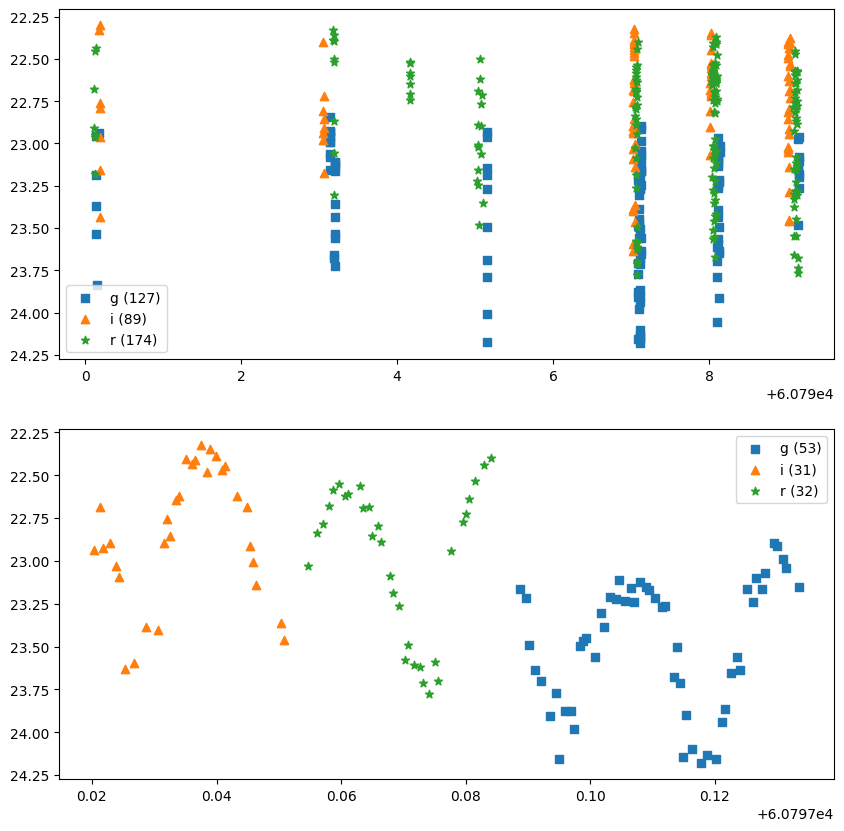

In [10]:
# Repro Figure 8 from the paper
def show_figure8(obs_time, otime, mag, first_day: float):
    """Draw figure similar to Figure8 in the paper.
    Parameters:
    -----------
    obs_time:
      sorted list of all observation times for the given object

    """
    # print(pc.min(otime["g"].mjd()), pc.max(otime["g"].mjd()))
    _fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    axs[0].scatter(otime["g"].mjd().to_pylist(), mag["g"].to_pylist(), marker="s", c="tab:blue", label=f"g ({len(mag['g'])})")
    axs[0].scatter(otime["i"].mjd().to_pylist(), mag["i"].to_pylist(), marker="^", c="tab:orange", label=f"i ({len(mag['i'])})")
    axs[0].scatter(otime["r"].mjd().to_pylist(), mag["r"].to_pylist(), marker="*", c="tab:green", label=f"r ({len(mag['r'])})")
    axs[0].legend()
    axs[0].invert_yaxis()

    # Find the night with the observation count matching Figure 8 in the paper
    beginning_of_time = pc.min(obs_time).as_py() - 0.25
    start_time = beginning_of_time + first_day # 6 is the number that matched the count
    end_time = start_time + 1.5 # make sure to get the whole night

    selected_times = {}
    selected_mags = {}
    for color in ["g", "i", "r"]:
        index = pc.and_(pc.greater(otime[color].mjd(), start_time), pc.less(otime[color].mjd(), end_time))
        selected_times[color] = otime[color].mjd().to_numpy()[index]
        selected_mags[color] = mag[color].to_numpy()[index]
    axs[1].scatter(selected_times["g"], selected_mags["g"], marker="s", c="tab:blue", label=f"g ({len(selected_mags['g'])})")
    axs[1].scatter(selected_times["i"], selected_mags["i"], marker="^", c="tab:orange", label=f"i ({len(selected_mags['i'])})")
    axs[1].scatter(selected_times["r"], selected_mags["r"], marker="*", c="tab:green", label=f"r ({len(selected_mags['r'])})")
    axs[1].legend()
    axs[1].invert_yaxis()

    plt.show()

show_figure8(mm81_obstime, mm81_otime, mm81_mag, 6)

## Helper functions and tables for H,G12* phase dependency functions

In [11]:
# Basis functions Phi1, Phi2, Phi3 from Penttila et al. (2016)
# Hermite cubic spline (Appendix A, Eq. A.1).
# xs in degrees; derivatives ds are in d(y)/d(alpha_rad) as given in Penttila Table A.2/A.3.
def _hermite_spline(x_deg, xs_deg, ys, ds_per_rad):
    x  = np.deg2rad(np.asarray(x_deg, dtype=float))
    xs = np.deg2rad(xs_deg)
    scalar = x.ndim == 0
    x = np.atleast_1d(x)
    j = np.clip(np.searchsorted(xs, x, side='right') - 1, 0, len(xs) - 2)
    dx = xs[j+1] - xs[j]
    dy = ys[j+1] - ys[j]
    t  = (x - xs[j]) / dx
    a  = ds_per_rad[j] * dx - dy
    b  = -ds_per_rad[j+1] * dx + dy
    result = (1 - t)*ys[j] + t*ys[j+1] + t*(1 - t)*((1 - t)*a + t*b)
    return float(result[0]) if scalar else result

# Spline knots Table A.2: xi1
_XI1_X = np.array([7.5,  30.,  60.,  90.,  120.,  150.])
_XI1_Y = np.array([7.5e-1, 3.3486016e-1, 1.3410560e-1, 5.1104756e-2, 2.1465687e-2, 3.6396989e-3])
_XI1_D = np.array([-1.9098593, -5.5463432e-1, -2.4404599e-1, -9.4980438e-2, -2.1411424e-2, -9.1328612e-2])

# xi2
_XI2_X = np.array([7.5,  30.,  60.,  90.,  120.,  150.])
_XI2_Y = np.array([9.25e-1, 6.2884169e-1, 3.1755495e-1, 1.2716367e-1, 2.2373903e-2, 1.6505689e-4])
_XI2_D = np.array([-5.7295780e-1, -7.6705367e-1, -4.5665789e-1, -2.8071809e-1, -1.1173257e-1, -8.6573138e-8])

# xi3 Table A.3
_XI3_X = np.array([0.,  0.3,  1.,  2.,  4.,  8.,  12.,  20.,  30.])
_XI3_Y = np.array([1.0, 8.3381185e-1, 5.7735424e-1, 4.2144772e-1, 2.3174230e-1,
                   1.0348178e-1, 6.1733473e-2, 1.6107006e-2, 0.0])
_XI3_D = np.array([-1.0630097e-1, -4.1180439e1, -1.0366915e1, -7.5784615, -3.6960950,
                   -7.8605652e-1, -4.6527012e-1, -2.0459545e-1, 0.0])

def _phi1(alpha_deg):
    a = np.asarray(alpha_deg, dtype=float)
    lin = 1.0 - (6.0 / np.pi) * np.deg2rad(a)
    spl = _hermite_spline(a, _XI1_X, _XI1_Y, _XI1_D)
    return np.where(a <= 7.5, lin, spl)

def _phi2(alpha_deg):
    a = np.asarray(alpha_deg, dtype=float)
    lin = 1.0 - (9.0 / (5.0 * np.pi)) * np.deg2rad(a)
    spl = _hermite_spline(a, _XI2_X, _XI2_Y, _XI2_D)
    return np.where(a <= 7.5, lin, spl)

def _phi3(alpha_deg):
    a = np.asarray(alpha_deg, dtype=float)
    spl = _hermite_spline(a, _XI3_X, _XI3_Y, _XI3_D)
    return np.where(a <= 30.0, spl, 0.0)


In [12]:
# Sanity check using table B.4 from page 25 of Pentilla.
# Their value for phi_i(0) is wrong (should be 1, they have 0),
# the rest should match
for alpha in [0.0, 0.35, 2.0, 5.5, 75]:
    print(f"Alpha={alpha} phi1={_phi1(alpha)} phi2={_phi2(alpha)} phi3={_phi3(alpha)}")

Alpha=0.0 phi1=1.0 phi2=1.0 phi3=1.0
Alpha=0.35 phi1=0.9883333333333333 phi2=0.9965 phi3=0.7996871994700306
Alpha=2.0 phi1=0.9333333333333333 phi2=0.98 phi3=0.42144772
Alpha=5.5 phi1=0.8166666666666667 phi2=0.945 phi3=0.15818479410857114
Alpha=75 phi1=0.08284886043611442 phi2=0.21084407701762375 phi3=0.0


In [13]:
# Values for H-only fit from page 14 of Shevchenko et al (2016). 
# Table 4: type, G1, G2
# This is used when `kind` is specified as positive [0, 5]
G_VALUES = [('S', 0.26, 0.38), ('M', 0.27, 0.35),
            ('E', 0.15, 0.60), ('C', 0.82, 0.02),
            ('P', 0.83, 0.05), ('D', 0.96, 0.02)]

def hg12star_correction(alpha_deg: np.ndarray, kind: Optional[int] = None, g12star: Optional[float] = None) -> np.ndarray:
    """Compute alpha correction using H,G12* approximation.

    Parameters:
    -----------
    alpha_deg: np.ndarray
      angle Sun-object-observer in degrees
    kind: Optional[int], range [0,5], default None
      index into known G_VALUES
    g12star: Optional[float], default None
      value of G12* parameter to use for computing G1 and G2

    Exactly one of kind and g12star should be provided.

    Returns:
    --------
    Magnitude correction for the given alphas.
    """
    if g12star is not None:
        G1 = 0.84293649 * g12star
        G2 = 0.53513350 * (1.0 - g12star)
    else:
        G1, G2 = G_VALUES[kind][1], G_VALUES[kind][2]
    G3 = 1.0 - G1 - G2
    combined = G1 * _phi1(alpha_deg) + G2 * _phi2(alpha_deg) + G3 * _phi3(alpha_deg)
    combined = np.maximum(combined, 1e-10)
    return -2.5 * np.log10(combined)

## High-order Fourier Analysis

In [14]:
def _adjust_inputs_for_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput,
                              obs_time: pa.DoubleArray, quiet: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    """Correct observations for the light time and distance.
    Returns corrected observed times and magnitudes in the original order."""
    # Sanity that the arrays are sorted, so we can just match indexes
    deltas = pc.subtract(obs_time, range_inputs.obs_time.mjd())
    assert pc.max(pc.abs(deltas)).as_py() < 1e-9

    observed_mags = np.array([float(v) for v in observation_table["mag"]])
    helio_r = range_inputs.sun_range.to_numpy()
    topo_delta = range_inputs.obs_range.to_numpy()
    alpha = range_inputs.angle.to_numpy()
    if not quiet:
        print(f"Alpha range {np.min(alpha)} - {np.max(alpha)}")

    # Page 6, section 3.1
    # Subtract 5*log10(r*delta) from observational magnitudes
    # print(f"Sizes V={observed_mags.shape}, r={helio_r.shape}, delta={topo_delta.shape}, alpha={alpha.shape}")
    observed_mags = observed_mags - 5*np.log10(helio_r * topo_delta)

    # Correct timing for speed of light: t = t_obs - delta/c
    observed_time = obs_time - topo_delta / DE44X_CONSTANTS["C"]
    return observed_time, observed_mags

def _get_freqs(fmin: float, fmax: float, arc_len: float) -> np.ndarray:
    """Returns the list of frequencies to try in Fourier analysis."""
    N = int(30 * arc_len * (fmax - fmin))
    return np.linspace(fmin, fmax, num=N)

In [15]:
def _fit_fourier(freq: float, k: int, obs_v, obs_t, alpha_deg, bands, weights, kind: Optional[int]) -> Tuple[np.ndarray, float, int]:
    # kind == None means use c1,c2. kind < 0 means fit G12*, kind >= 0 selects from G_VALUES
    # Returned values are [c1, c2, A1, B1, ..., Ak, Bk, H_g, H_i, H_r, H_u], length 2+2*k+4
    # In case G12* fit, c1=1e6, c2=G12*. In case known G1,G2, c1=index of G_VALUES and c2=1e6

    # return values, sigma2, np.sum(included)

    use_g12star = kind is not None and kind < 0

    # Figure out num parameters and size of matrices
    num_obs = len(obs_v)
    if use_g12star:
        num_params = 1 + 2*k + 4 # include g12*
        A = np.zeros((num_obs, num_params-1))
    else:
        if kind is not None:
            num_params = 2*k + 4
            obs_v = obs_v - hg12star_correction(alpha_deg, kind=kind)
        else:
            num_params = 2 + 2*k + 4 # include c1, c2
        A = np.zeros((num_obs, num_params))
    params = np.zeros(num_params)

    # Populate A matrix based on the choice of alpha dependency function
    alpha_rad = np.deg2rad(alpha_deg)
    if kind is None:
        # Model phi(alpha) = c1*alpha + c2*alpha^2
        # X=[c1, c2, A1, B1, ..., Ak, Bk, Hg, Hi, Hr, Hu ]
        A[:, 0] = alpha_rad # *c1
        A[:, 1] = alpha_rad*alpha_rad # *c2
        idx = 2
    else:
        # Either known kind or fitting g12*. In both cases nothing goes into
        # the A matrix except Fourier cooeficients and H
        idx = 0

    # Fourier coefficients for
    # g (t ) = sum(j=1:k) Aj*cos (2 fjt ) + Bj*sin (2 fjt ) for k 2:6
    base = 2*np.pi*freq*obs_t
    for j in range(1, k+1):
        arg = base * j
        A[:, idx] = np.cos(arg)
        A[:, idx+1] = np.sin(arg)
        idx+=2

    # Pick color. TODO: use matrix operations here
    color_offset = {'g': 0, 'i': 1, 'r': 2, 'u': 3}
    for i in range(num_obs):
        color = bands[i].as_py()
        try:
            A[i, idx+color_offset[color]] = 1
        except KeyError:
            raise BaseException(f"Bad color [{color}] index {i}")

    # Build weighted matrices. obs_v is already adjusted if we use known G1,G2
    W = np.diag(np.sqrt(weights))
    Aw = np.dot(W, A)
    Bw = np.dot(obs_v, W)

    # Function for computing residuals if using non-linear least squares
    # This is used only if we have g12star part, but make it generic unless
    # that if is somehow computationally expensive (compared to the matrix ops -
    # doubt it)
    included = np.array([True] * num_obs)
    def func(par):
        if use_g12star:
            corr = hg12star_correction(alpha_deg, g12star=par[0])
            return Aw[included, :] @ par[1:] + np.dot(corr, W)[included] - Bw[included]
        return Aw[included, :] @ par - Bw[included]

    # May need to throw away outliers
    converged = False
    while not converged:
        # Use regular least squares unless we have to fit g12star
        if use_g12star:
            # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html
            lb = [-np.inf] * len(params)
            ub = [np.inf] * len(params)
            lb[0], ub[0] = 0.0, 1.0 # bounds for g12*
            result = scipy.optimize.least_squares(func, params, bounds=(lb, ub), verbose=0)
            if not result.success:
                print(f"Non-linear least squares failed:\n{result}")
                return np.zeros(2 + 2*k + 4), -1, -1
            values = result.x
            print(f"Mask {result.active_mask}")
        else:
            values, _residuals, _rank, _singulars = np.linalg.lstsq(Aw[included, :], Bw[included])

        # Compute p_j*(Oj-Cj)^2
        # This includes already rejected, it's okay
        if use_g12star:
            corr = hg12star_correction(alpha_deg, g12star=values[0])
            res = (A @ values[1:] + corr - obs_v)**2 * weights
        else:
            res = (A @ values - obs_v)**2 * weights 
        n_incl = np.sum(included)
        # Discard rejected when computing sigma^2
        sigma2 = np.sum(res[included]) / (n_incl - num_params) 
        # No masking needed here, because included accumulates
        outliers = res > 9*sigma2
        # Converged if there are no NEW outliers
        converged = np.sum(outliers[included]) == 0
        included = included & ~outliers

    # Pad values for G12* cases
    if use_g12star:
        values = np.concatenate([[1e6], values])
    elif kind is not None:
        values = np.concatenate([[kind, 1e6], values])
    return values, num_obs * sigma2 / np.sum(weights), np.sum(included)


def run_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput, obs_time: pa.DoubleArray,
                kind: Optional[int], freqs) -> Tuple[FourierFitResult, float]:
    observed_time, observed_mags = _adjust_inputs_for_fourier(observation_table, range_inputs, obs_time)
    arc_length = np.max(obs_time) - np.min(obs_time)
    print(f"Freqs count {freqs.shape}, arc length={arc_length}")

    alpha = np.deg2rad(range_inputs.angle.to_numpy())
    weights = 1 / (np.array([float(w) for w in observation_table["rmsmag"]]) ** 2)

    # Page 7: for each k, find freq that gives minimum sigma2 for that k
    rows_k, rows_sigma2, rows_freq, rows_n_included, rows_values = [], [], [], [], []
    for k in range(2, 7):
        best_sigma2 = np.inf
        best_fit = None
        best_freq = np.inf
        best_size = np.inf
        idx = 0
        for f in freqs:
            if kind is not None and kind < 0:
                print(f"k={k} idx={idx} out of {len(freqs)}")
                idx += 1
            X, sigma2, n_incl = _fit_fourier(f, k, observed_mags, observed_time, alpha, observation_table["band"], weights, kind)
            if sigma2 < best_sigma2:
                best_sigma2 = sigma2
                best_fit = X
                best_freq = f
                best_size = n_incl
        print(f"For k={k} got best freq {best_freq} with sigma={best_sigma2} H={best_fit[-4:]} N={best_size} -> period = {24.0 / best_freq} h")
        rows_k.append(k)
        rows_sigma2.append(best_sigma2)
        rows_freq.append(best_freq)
        rows_n_included.append(int(best_size))
        rows_values.append(best_fit.tolist())

    return FourierFitResult.from_kwargs(
        k=rows_k,
        sigma2=rows_sigma2,
        freq=rows_freq,
        n_included=rows_n_included,
        values=rows_values,
    ), arc_length

In [16]:
def best_row_by_f(fourier_result: FourierFitResult, alpha: float=0.05) -> FourierFitResult:
    """Select the best Fourier order k using an F-test.
    Returns the single winning row as a FourierFitResult."""
    best_row = 0
    best_row_changed = True
    while best_row_changed:
        best_row_changed = False
        k_i      = fourier_result.k[best_row].as_py()
        sigma2_i = fourier_result.sigma2[best_row].as_py()
        size_i   = fourier_result.n_included[best_row].as_py()
        for j in range(best_row + 1, len(fourier_result)):
            k_j      = fourier_result.k[j].as_py()
            sigma2_j = fourier_result.sigma2[j].as_py()
            size_j   = fourier_result.n_included[j].as_py()
            F = sigma2_i / sigma2_j
            p = 1 - scipy.stats.f.cdf(F, size_i - 1, size_j - 1)
            print(f"K={k_i},{k_j} sigmas2={sigma2_i},{sigma2_j} F={F}, p={p}")
            if p < alpha and sigma2_j < sigma2_i:
                print(f"Switch best row to {j}")
                best_row = j
                best_row_changed = True
                break
    best = fourier_result.take([best_row])
    print(f"Best row={best_row} for k={best.k[0].as_py()}")
    return best


def amplitude(fit: FourierFitResult, alpha_avg: float) -> Tuple[float, float, float, float, float, int]:
    """Compute amplitude, colors, and elongation from the best-fit Fourier row.

    Parameters
    ----------
    fit : single-row FourierFitResult (the winner from best_row_by_f)
    alpha_avg : mean phase angle [degrees]

    Returns
    -------
    ampl, color_gr, color_gi, color_ri, elongation, count_local_maxima
    """
    k      = fit.k[0].as_py()
    freq   = fit.freq[0].as_py()
    values = fit.values[0].as_py()  # [c1, c2, A1, B1, ..., Ak, Bk, H_g, H_i, H_r]

    period_days = 1 / freq
    sample = np.linspace(0, 2*period_days, num=1000)
    base = 2*np.pi*freq*sample
    G = np.zeros(len(sample))
    assert len(values) == 2 + k*2 + 4
    for j in range(k):
        arg = base * (j + 1)
        G += values[2+2*j]   * np.cos(arg)
        G += values[2+2*j+1] * np.sin(arg)
    ampl = np.max(G) - np.min(G)

    max_count = sum(1 for i in range(1, len(G)-1) if G[i-1] < G[i] and G[i] >= G[i+1])
    print(f"Count of local maxima {max_count}, G size {len(G)}")
    print(f"Amplitude {ampl}")

    H_g = values[2+2*k]
    H_i = values[2+2*k+1]
    H_r = values[2+2*k+2]
    assert 2+2*k+3 == len(values)-1
    print(f"Colors g-r={H_g-H_r} g-i={H_g-H_i} r-i={H_r-H_i}")

    A0 = ampl / (1 + 0.02*alpha_avg)
    elongation = 10 ** (0.4*A0)
    print(f"Elongation={elongation}")
    return ampl, H_g-H_r, H_g-H_i, H_r-H_i, elongation, max_count

In [17]:
def run_complete_fourier(object_id: str, kind: Optional[int], min_freq: float = 0.1667, max_freq: float = 500, preselect_freq: bool = True) -> FourierFullResult:
    """Run the complete Fourier rotational-period pipeline for one object.

    Returns a single-row FourierFullResult with the best-fit summary
    and the winning FourierFitResult row embedded as intermediate_result.
    """
    selection, obstime, _otime, _mag = subset_data(object_id, all_data)
    inputs = cache_or_query_rotational_period_inputs(object_id, "X05", obstime)
    print(f"All colors {selection['band'].unique().to_pylist()}")

    arc_length = np.max(obstime) - np.min(obstime)
    freqs = _get_freqs(min_freq, max_freq, arc_length)
    if kind is not None and kind < 0 and preselect_freq:
        print(f"Computing frequency first to make G12* fitting easier, use type '{G_VALUES[0][0]}'")
        fit, arc_length = run_fourier(selection, inputs, obstime, 0, freqs)
        best_fit = best_row_by_f(fit)
        freq = best_fit.freq[0].as_py()
        print(f"Selected frequency {freq} for period {24.0 / freq} h")
        fit, arc_length = run_fourier(selection, inputs, obstime, kind, np.array([freq]))
    else:
        fit, arc_length = run_fourier(selection, inputs, obstime, kind, freqs)

    best_fit = best_row_by_f(fit)
    ampl, color_gr, color_gi, color_ri, elongation, max_count = amplitude(
        best_fit, np.average(inputs.angle)
    )
    print(f"Angle in degrees: average={np.average(inputs.angle)}, mean={np.mean(inputs.angle)}, median={np.median(inputs.angle)}")
    period_h = 24.0 / best_fit.freq[0].as_py()
    if max_count < 3:
        print(f"Double the period, count of maximums is {max_count}")
        period_h *= 2
    return FourierFullResult.from_kwargs(
        object_id=[object_id],
        num_obs = [len(obstime)],
        arc_days = [arc_length],
        intermediate_result=[pickle.dumps(fit)],
        selected_k=[best_fit.k[0].as_py()],
        count_local_maxima=[max_count],
        period_h=[period_h],
        amplitude=[ampl],
        color_gr=[color_gr],
        color_gi=[color_gi],
        color_ri=[color_ri],
        elongation=[elongation],
    )

In [18]:
def run_complete_fourier_with_cache(object_id: str, 
                                    kind: Optional[int],
                                    cache_file: str = "../data/fourier_outputs.parquet",
                                    force_query: bool = False) -> FourierFullResult:
    try:
        output_data = FourierFullResult.from_parquet(cache_file)
        print(f"Read total {len(output_data)} records")
    except:
        print(f"Failed to read {cache_file}")
        output_data = FourierFullResult.empty()
    result = output_data.apply_mask(pc.equal(output_data.object_id, object_id))
    if force_query or len(result) == 0:
        print(f"Recomputing Fourier for object {object_id}")
        result = run_complete_fourier(object_id, kind)
        output_data = qv.concatenate([
            output_data.apply_mask(pc.not_equal(output_data.object_id, object_id)),
            result,
            ])
        output_data.to_parquet(cache_file)
    return result
   

## Viz functions that may be occasionally helpful

In [19]:
def viz_vs_data(id, day, inputs, id_fit):
    k, sigma2, freq, values, size = id_fit
    fig, ax = plt.subplots(1,1, figsize=(10, 5))
    id_selection, id_obstime, id_otime, id_mag = subset_data(id, all_data)
    id_obstime = id_obstime.to_numpy()
    mag = id_selection["mag"].cast('float').to_numpy()
    start_time = np.min(id_obstime) - 0.25
    if day is not None:
        start_time += day
        index = (id_obstime > start_time) & (id_obstime < (start_time+1))
    else:
        index = np.array([True] * len(id_obstime))

    alpha = np.deg2rad(inputs.angle)[0]
    alpha_corr = values[0]*alpha + values[1]*alpha*alpha
    helio_r = inputs.sun_range.to_numpy()[0]
    topo_delta = inputs.obs_range.to_numpy()[0]
    mag_corr = 5*np.log10(helio_r * topo_delta)


    times = id_obstime[index] # np.linspace(np.min(id_obstime[index]), np.max(id_obstime[index]), num=100)
    base = 2*np.pi*freq*times
    G = np.zeros((len(times)))
    assert len(values) == 2+k*2+4
    for j in range(0, k):
        arg = base * (j+1)
        G += values[2+2*j]*np.cos(arg)
        G += values[2+2*j+1]*np.sin(arg)
        # print(f"A{j} -> {2+2*j}")
    H_g = values[2+2*k]
    H_i = values[2+2*k+1]
    H_r = values[2+2*k+2]
    G += H_r + alpha_corr + mag_corr
    print(f"Corrections alpha={alpha_corr} mag={mag_corr} ampl={np.max(G)-np.min(G)}")

    # index = range(100, 200)
    ax.scatter(id_obstime[index], mag[index])
    ax.plot(times, G, color="r")
    ax.yaxis_inverted()
    fig.show()

# viz_vs_data(mm81_id, 7, mm81_inputs, best_fit_mm81)

## Compare our results with the paper
Using the caching version here on purpose.

In [20]:
def compare_our_fourier(object_id: str, kind: Optional[int], force_query=False) -> None:
    ours = run_complete_fourier_with_cache(object_id, kind, force_query=force_query)
    k = ours.selected_k[0].as_py()
    best_row = pickle.loads(ours.intermediate_result[0])[k-2]
    theirs = paper_table2.apply_mask(pc.equal(paper_table2.designation, object_id))
    print(f"For {object_id} F/LSM, arc {ours.arc_days[0]} vs {theirs.arc_days[0]}")
    print(f"Num observations {ours.num_obs[0]} vs {theirs.num_observations[0]}")
    print(f"Selected k={k}, used observations {best_row.n_included[0].as_py()}")
    print(f"Period:   {ours.period_h[0]} vs {theirs.period_fourier[0]} / {theirs.period_lsm[0]}")
    print(f"Amplitude {ours.amplitude[0]} vs {theirs.amplitude_fourier[0]} / {theirs.amplitude_lsm[0]}")
    print(f"G-R       {ours.color_gr[0]} vs {theirs.g_minus_r_fourier[0]} / {theirs.g_minus_r_lsm[0]}")
    print(f"G-I       {ours.color_gi[0]} vs {theirs.g_minus_i_fourier[0]} / {theirs.g_minus_i_lsm[0]}")
    print(f"R-I       {ours.color_ri[0]} vs {theirs.r_minus_i_fourier[0]} / {theirs.r_minus_i_lsm[0]}")
    print(f"Elongation {ours.elongation[0]} vs {theirs.axial_elongation[0]}")
    print(f"Magnitudes {best_row.values[0].as_py()[-4:]}, c1,c2,G12 {best_row.values[0].as_py()[:2]}")


In [21]:
def run3_forid(object_id):
    print("c1,c2 version")
    compare_our_fourier(object_id, kind=None, force_query=True)
    # Don't run known G1,G2, because it will be run as part of the G12* optimization
    #print(f"\n\nKnown G1, G2 for type 0 = '{G_VALUES[0][0]}'")
    #compare_our_fourier(object_id, kind=0, force_query=False)
    print(f"\n\nFit G12*")
    compare_our_fourier(object_id, kind=-1, force_query=True)

# run3_forid("2025 MM81")


In [ ]:
# compare_our_fourier("2025 MM81", kind=-1, force_query=True)
# stop


Read total 26 records
Recomputing Fourier for object 2025 MM81
For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174, u 0
Read total 22466 records
All colors ['r', 'g', 'i']
Computing frequency first to make G12* fitting easier, use type 'S'
Alpha range 18.2055 - 22.3731
Freqs count (135492,), arc length=9.035824999999022
For k=2 got best freq 21.7956099490003 with sigma=0.010589494760901442 H=[22.34841176 21.70823121 21.82826929  0.        ] N=387 -> period = 1.1011391769332342 h
For k=3 got best freq 21.7956099490003 with sigma=0.009668975066506935 H=[22.35359123 21.70988098 21.83404183  0.        ] N=388 -> period = 1.1011391769332342 h
For k=4 got best freq 21.7956099490003 with sigma=0.008121802973503066 H=[22.3707235  21.72273804 21.84742941  0.        ] N=388 -> period = 1.1011391769332342 h
For k=5 got best freq 21.7956099490003 with sigma=0.00795723775120

In [22]:
# Warm up dump for everything for G12* optimization
for name in paper_table2.designation:
    compare_our_fourier(name.as_py(), kind=-1, force_query=False)

Read total 66 records
For 2025 MA19 F/LSM, arc 9.03377790509694 vs 9
Num observations 429 vs 447
Selected k=6, used observations 428
Period:   8.871315843117992 vs 8.9 / 8.9
Amplitude 1.1282739936645925 vs 1.0 / 0.7
G-R       0.42981769994178975 vs 0.46 / 0.44
G-I       0.542113491778764 vs 0.55 / 0.49
R-I       0.11229579183697425 vs 0.08 / 0.05
Elongation 2.3115039595815223 vs 2.1
Magnitudes [18.978841140685482, 18.436727648906718, 18.549023440743692, 0.0], c1,c2,G12 [1000000.0, 2.3152582451793725e-07]
Read total 66 records
For 2025 MA45 F/LSM, arc 12.043866203704965 vs 12
Num observations 120 vs 140
Selected k=2, used observations 120
Period:   1.6330151860966802 vs 1.6 / 1.6
Amplitude 0.5224015833091071 vs 0.6 / 0.7
G-R       0.4296037360106233 vs 0.45 / 0.35
G-I       0.6282065146981566 vs 0.6 / 0.65
R-I       0.1986027786875333 vs 0.14 / 0.3
Elongation 1.4413138630803555 vs 1.5
Magnitudes [20.481272240073075, 19.85306572537492, 20.05166850406245, 20.93866532875457], c1,c2,G12 [10

In [ ]:
paper_periods = {row.designation[0].as_py(): row.period_fourier[0].as_py() for row in paper_table2}
paper_elongations = {row.designation[0].as_py(): row.axial_elongation[0].as_py() for row in paper_table2}
our_fourier = FourierFullResult.from_parquet("../data/fourier_outputs.g12star.parquet")

our_periods = {row.object_id[0].as_py(): row.period_h[0].as_py() for row in our_fourier}
our_elongations = {row.object_id[0].as_py(): row.elongation[0].as_py() for row in our_fourier}
deltas_periods = {key: our_periods[key]-paper_periods[key] for key in paper_periods.keys()}
deltas_elongations = {key: our_elongations[key]-paper_elongations[key] for key in paper_elongations.keys()}

all_ids = {row.designation[0].as_py() for row in paper_table2}
wrong_data_counts = {name for name in all_ids if paper_table2.apply_mask(pc.equal(paper_table2.designation, name)).num_observations[0].as_py() > our_fourier.apply_mask(pc.equal(our_fourier.object_id, name)).num_obs[0].as_py()}
print(f"Count of mismatched num obs objects: {len(wrong_data_counts)}")

Count of mismatched num obs objects: 47


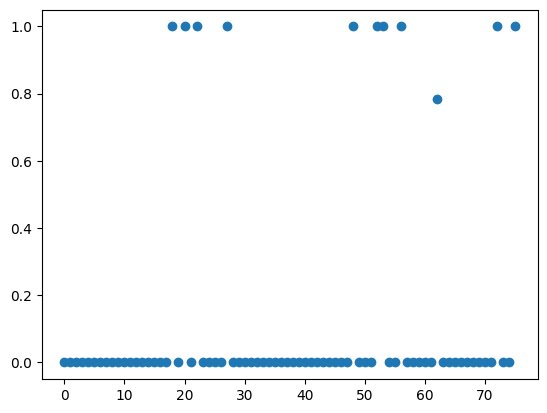

Count near zero: 65, near one 10
Objects with middle values: ['2025 MV31']


In [48]:
# Pull out G12*
g12star = {}
for row in our_fourier:
    k = row.selected_k[0].as_py()
    best_row = pickle.loads(row.intermediate_result[0])[k-2]
    g12star[row.object_id[0].as_py()] = best_row.values[0].as_py()[1]
plt.figure()
plt.scatter(range(len(g12star)), list(g12star.values()))
plt.show()
g12array = np.array(list(g12star.values()))
print(f"Count near zero: {sum(g12array < 0.01)}, near one {sum(g12array>0.99)}")
print(f"Objects with middle values: {[k for k,v in g12star.items() if v > 0.01 and v < 0.99]}")

76 76


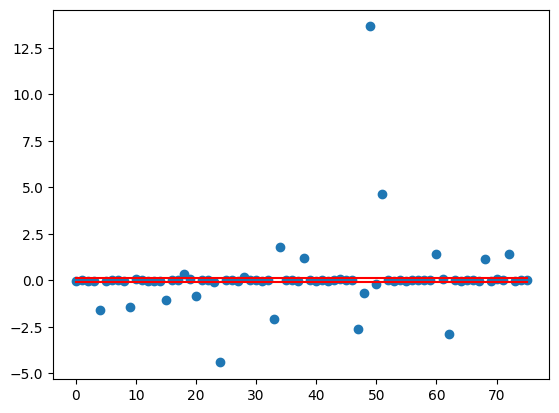

1
{'2025 MP71': 13.649985639018828}


In [ ]:
print(len(our_fourier), len(paper_periods))
plt.figure()
plt.scatter(range(len(deltas_periods)), list(deltas_periods.values()))
plt.plot(range(len(deltas_periods)), [0.1]*len(deltas_periods), color='r')
plt.plot(range(len(deltas_periods)), [-0.1]*len(deltas_periods), color='r')
plt.show()
bad_fits = {k:v for k, v in deltas_periods.items() if abs(v)>5}
print(f"Really bad periods: {bad_fits}")

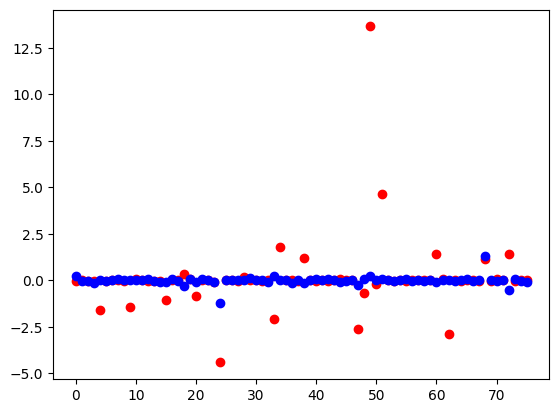

In [ ]:
plt.figure()
plt.scatter(range(len(deltas_periods)), list(deltas_periods.values()), c='r')
plt.scatter(range(len(deltas_elongations)), list(deltas_elongations.values()), c='b')
plt.show()

With matching input data sizes 29


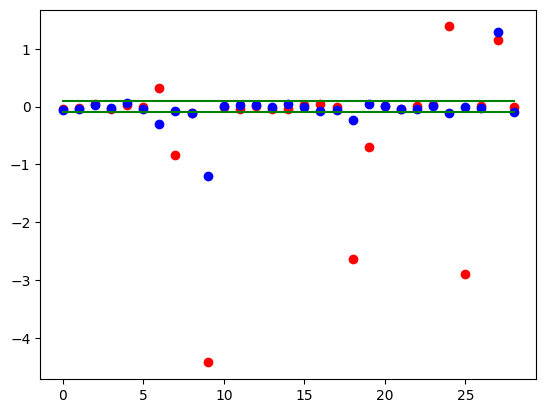

In [40]:
matching_periods = {k: v for k, v in deltas_periods.items() if k not in wrong_data_counts}
matching_elongations = {k: v for k, v in deltas_elongations.items() if k not in wrong_data_counts}
print(f"With matching input data sizes {len(matching_periods)}")
plt.figure()
plt.scatter(range(len(matching_periods)), list(matching_periods.values()), c='r')
plt.scatter(range(len(matching_elongations)), list(matching_elongations.values()), c='b')
plt.plot(range(len(matching_periods)), [0.1]*len(matching_periods), color='g')
plt.plot(range(len(matching_periods)), [-0.1]*len(matching_periods), color='g')
plt.show()


In [39]:
actually_bad = {v for v in wrong_data_counts if abs(deltas_periods[v]) > 0.5 or abs(deltas_elongations[v] > 0.2)}
print(f"Total number with wrong data counts {len(wrong_data_counts)}, actually bad {len(actually_bad)}")

for key in actually_bad:
    compare_our_fourier(key, kind=-1, force_query=False)

Total number with wrong data counts 47, actually bad 10
Read total 76 records
For 2025 MM37 F/LSM, arc 9.025849999998172 vs 9
Num observations 291 vs 305
Selected k=2, used observations 289
Period:   3.70166885822328 vs 1.9 / 3.7
Amplitude 0.2982034068009607 vs 0.3 / 0.3
G-R       0.47425573845157487 vs 0.48 / 0.52
G-I       0.5944730270045255 vs 0.59 / 0.58
R-I       0.12021728855295066 vs 0.11 / 0.06
Elongation 1.2269847071704085 vs 1.2
Magnitudes [20.643475201859633, 20.049002174855108, 20.16921946340806, 0.0], c1,c2,G12 [1000000.0, 8.690259235304868e-09]
Read total 76 records
For 2025 MX69 F/LSM, arc 4.118531296291621 vs 4
Num observations 196 vs 213
Selected k=4, used observations 196
Period:   9.135275004639245 vs 7.7 / 9.1
Amplitude 0.8865281454421956 vs 1.3 / 0.7
G-R       0.549177308685092 vs 0.49 / 0.52
G-I       0.47762752746933046 vs 0.56 / 0.53
R-I       -0.0715497812157615 vs 0.06 / 0.01
Elongation 1.8622246527782704 vs 2.4
Magnitudes [20.29996627262685, 19.82233874515752